In [ ]:
#Import CSVCSV
#mengimpor file csv dari spreed sheets  agar csv bisa dibaca oleh program
from google.colab import files
uploaded = files.upload()

Saving tracer_study_prodi.csv to tracer_study_prodi.csv


In [ ]:
#Mengolah Data CSV
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('tracer_study_prodi.csv')

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df

,Prodi,Jenis_Data,Kategori,Jumlah
0,Arsitektur,Lama Mendapat Kerja,<6 Bulan,34
1,Arsitektur,Lama Mendapat Kerja,>6 Bulan,4
2,Arsitektur,Kesesuaian Kerja,Setingkat Lebih Tinggi,5
3,Arsitektur,Kesesuaian Kerja,Tingkat Yang Sama,32
4,Arsitektur,Kesesuaian Kerja,Setingkat Lebih Rendah,1
5,Arsitektur,Tempat Kerja,BUMN/BUMD,1
6,Arsitektur,Tempat Kerja,Institusi Multilateral,0
7,Arsitektur,Tempat Kerja,Instansi Pemerintah,1
8,Arsitektur,Tempat Kerja,Lainnya,7
9,Arsitektur,Tempat Kerja,Non Profit,1


In [ ]:
#Cleaning Data
df['Prodi'] = df['Prodi'].str.strip()
df['Jenis_Data'] = df['Jenis_Data'].str.strip()
df['Kategori'] = df['Kategori'].str.strip()

df['Jumlah'] = pd.to_numeric(df['Jumlah'], errors='coerce')
df = df.dropna()

In [ ]:
#Fungsi 1 Menghitung total per-prodi
def total_per_prodi(data):
    return data.groupby('Prodi')['Jumlah'].sum().sort_values(ascending=False)

total = total_per_prodi(df)
print(total)

Prodi
Teknik Sipil                    328
Perencanaan Wilayah dan Kota    146
Desain Komunikasi Visual        133
Arsitektur                      114
Teknik Geomatika                100
Teknik Lingkungan                89
Arsitektur Lanskap               47
Teknik Kelautan                  47
Teknik Perkeretaapian            11
Name: Jumlah, dtype: int64


In [ ]:
#Fungsi 2 Analisis Cepat Kerja Alumni
def kerja_cepat(data):
    return data[
        (data['Jenis_Data'] == 'Lama Mendapat Kerja') &
        (data['Kategori'] == '<6 Bulan')
    ]

cepat = kerja_cepat(df)
print(cepat)

                           Prodi           Jenis_Data  Kategori  Jumlah
0                     Arsitektur  Lama Mendapat Kerja  <6 Bulan      34
12            Arsitektur Lanskap  Lama Mendapat Kerja  <6 Bulan      13
24      Desain Komunikasi Visual  Lama Mendapat Kerja  <6 Bulan      38
36  Perencanaan Wilayah dan Kota  Lama Mendapat Kerja  <6 Bulan      39
48              Teknik Geomatika  Lama Mendapat Kerja  <6 Bulan      32
60                  Teknik Sipil  Lama Mendapat Kerja  <6 Bulan     101
72               Teknik Kelautan  Lama Mendapat Kerja  <6 Bulan      13
84         Teknik Perkeretaapian  Lama Mendapat Kerja  <6 Bulan       3
96             Teknik Lingkungan  Lama Mendapat Kerja  <6 Bulan      26


In [ ]:
#Fungsi 3 Analisis TOP 5 Prodi tercepat mendapat pekerjaan
def top5_prodi(data):
    cepat = kerja_cepat(data)
    return cepat.sort_values(by='Jumlah', ascending=False).head(5)

top5 = top5_prodi(df)
print(top5)

                           Prodi           Jenis_Data  Kategori  Jumlah
60                  Teknik Sipil  Lama Mendapat Kerja  <6 Bulan     101
36  Perencanaan Wilayah dan Kota  Lama Mendapat Kerja  <6 Bulan      39
24      Desain Komunikasi Visual  Lama Mendapat Kerja  <6 Bulan      38
0                     Arsitektur  Lama Mendapat Kerja  <6 Bulan      34
48              Teknik Geomatika  Lama Mendapat Kerja  <6 Bulan      32


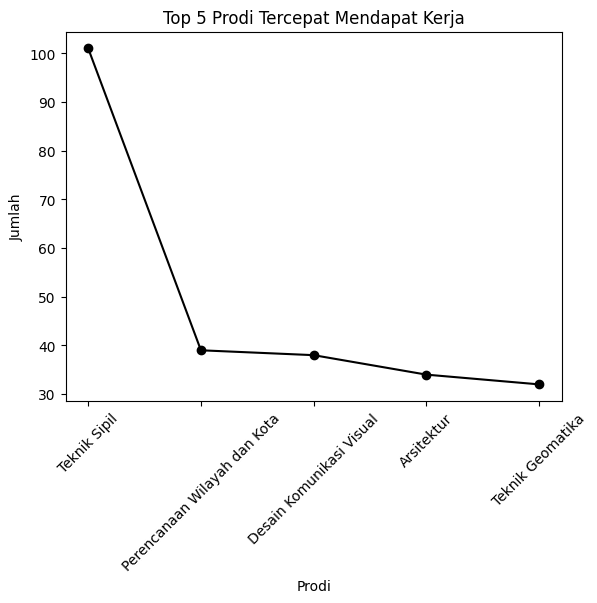

In [ ]:
#Visualisasi Grafik
#menggunakan tools matplotlib untuk membuat grafik top 5
plt.figure()

plt.plot(top5['Prodi'], top5['Jumlah'], color='black', marker='o')

plt.title('Top 5 Prodi Tercepat Mendapat Kerja')
plt.xlabel('Prodi')
plt.ylabel('Jumlah')

plt.xticks(rotation=45)

plt.show()

In [ ]:
top5.to_csv('hasil_top5_prodi.csv', index=False)

In [ ]:
#Export Hasil ke CSV
from google.colab import files
files.download('hasil_top5_prodi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>